Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



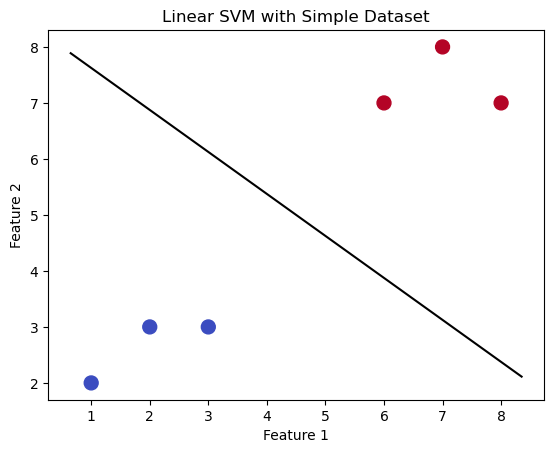

In [6]:
#Linear SVM
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# 🔹 Simple manually created dataset (linearly separable)
X = np.array([
    [1, 2],
    [2, 3],
    [3, 3],
    [6, 7],
    [7, 8],
    [8, 7]
])

y = np.array([0, 0, 0, 1, 1, 1])  # Two classes

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Linear SVM
model = SVC(kernel='linear')
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# 🔹 Plot points
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=100)

# Decision boundary
ax = plt.gca()
xlim = ax.get_xlim()

w = model.coef_[0]
b = model.intercept_[0]

x_points = np.linspace(xlim[0], xlim[1], 100)
y_points = -(w[0] * x_points + b) / w[1]

plt.plot(x_points, y_points, 'k-')

plt.title("Linear SVM with Simple Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

Accuracy: 0.9

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.88      0.78      0.82         9
           2       0.83      0.91      0.87        11

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



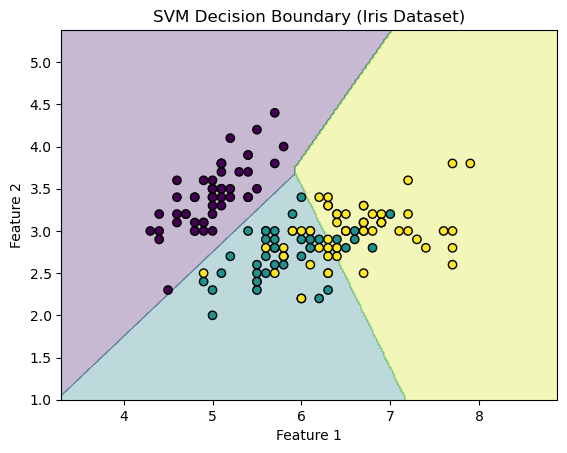

In [8]:
#Non-Linear SVM
# Build a model using SVM + Graph + Classification Report

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
iris = datasets.load_iris()

# Take only 2 features for visualization (important!)
X = iris.data[:, :2]  
y = iris.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train SVM model
model = SVC(kernel='linear')
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# 🔹 Plot Decision Boundary
h = 0.02  # step size

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("SVM Decision Boundary (Iris Dataset)")
plt.show()